In [3]:
import numpy as np
from scipy.sparse import coo_matrix

In [4]:
# first we will see what kind of data we have to deal with
import zipfile

with zipfile.ZipFile("hs_tomography.zip", "r") as zip_ref:
    zip_ref.printdir()
    zip_ref.extractall(".")

File Name                                             Modified             Size
hs_tomography/                                 2017-11-29 10:23:08            0
hs_tomography/alphas_195.npy                   2015-12-01 20:41:58         1512
hs_tomography/alphas_77.npy                    2015-12-01 20:41:58          800
hs_tomography/info.txt                         2017-11-29 17:08:42          516
hs_tomography/X_77.npy                         2017-11-29 10:23:08     10519326
hs_tomography/X_example.npy                    2017-11-29 09:57:16        18080
hs_tomography/y_195.npy                        2015-12-01 20:41:58       393880
hs_tomography/y_77.npy                         2015-12-01 20:41:58        39320


Note: 
> .npy files are numpy files saved on disk for future use.

# 1 Constructing the matrix X

In [5]:
# alphas_195 = np.load("./hs_tomography/alphas_195.npy")
# alphas_77 = np.load("./hs_tomography/alphas_77.npy")

In [6]:
def construct_X(M, alphas, Np = None):
    # if Np was not given we chose Np = [sqrt(2).M]
    if Np is None:
        Np = int(np.ceil(np.sqrt(2) * M))
        # choosing odd number 
        if Np % 2 == 0:
            Np += 1

    D = M * M
    N_angles = len(alphas)
    N = N_angles * Np


    # pixel coordinates
    x = np.arange(M) - (M - 1) / 2.0
    y = np.arange(M) - (M - 1) / 2.0

    # 2D grid and then flatten
    Xgrid, Ygrid = np.meshgrid(x, y, indexing='xy')
    coords = np.stack([Xgrid.ravel(), Ygrid.ravel()])   #shape -> (2, D)

    # p = n.T * C + S0

    # Pre-allocate lists for 
    rows_list = []
    columns_list = []
    data_list = []

    # loop over angels
    for io, alpha in enumerate(alphas):
        rad = np.radians(alpha)
        
        # Sensor direction (unit vector along the sensor array)
        n = np.array([np.cos(rad), np.sin(rad)])

        # projection of each pixel onto the sensor line
        # n = (cos(alpha), sin(alpha))
        # projection_of_x_y_on_n = x.cos(alpha) + y.sin(alpha)
        p = n[0] * coords[0] + n[1] * coords[1]     # shape(D, )
        
        # x = p + (Np - 1)/2
        # map to sensor index -> with centre element at index (Np - 1)/2
        idx_float = p + (Np - 1) / 2.0

        # left and right indices for interpolation
        i_left = np.floor(idx_float).astype(np.int32)
        i_right = i_left + 1
        frac = idx_float - i_left  #fraction to the right

        # validate indices and save them for left and right
        left_ok = (i_left >= 0) & (i_left < Np)
        right_ok = (i_right >= 0) & (i_right < Np)

        # left indices
        if np.any(left_ok):
            rows_list.append(io * Np + i_left[left_ok])
            columns_list.append(np.arange(D)[left_ok])
            data_list.append((1.0 - frac[left_ok]).astype(np.float32))

        if np.any(right_ok):
            rows_list.append(io * Np + i_right[right_ok])
            columns_list.append(np.arange(D)[right_ok])
            data_list.append(frac[right_ok].astype(np.float32))

    rows = np.concatenate(rows_list)
    columns = np.concatenate(columns_list)
    data = np.concatenate(data_list)

    X = coo_matrix((data, (rows, columns)), shape=(N, D), dtype=np.float32)
    return X.tocsc()

In [7]:
import matplotlib.pyplot as plt

Max absolute difference: 9.98e-01
Are they exactly equal (allowing tiny floating error)? False


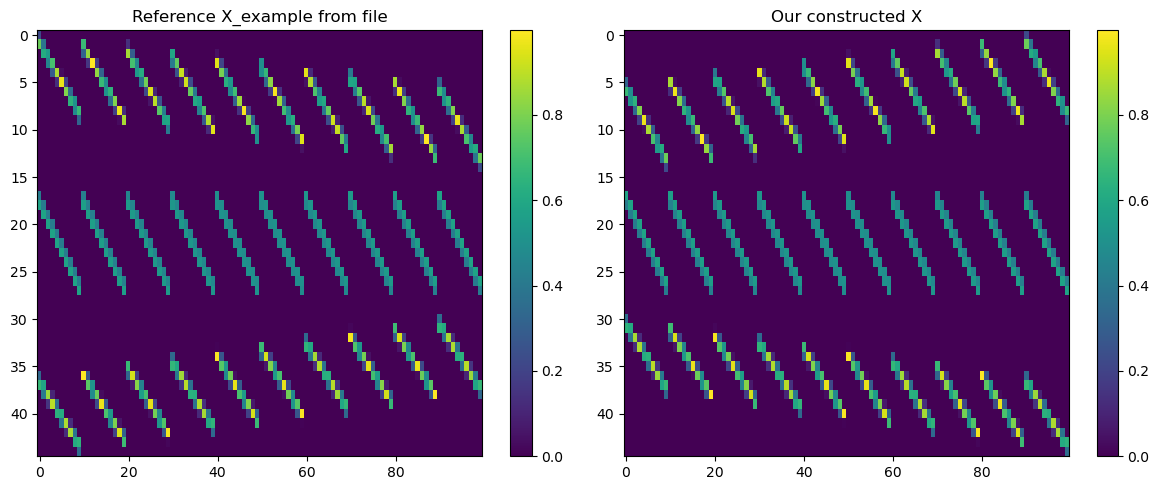

In [8]:
X_examaple = np.load("./hs_tomography/X_example.npy")

# Build the matrix X for m=10 and given angles
M_test = 10
alphas_test = np.array([-33, 1, 42])
Np_test = 15

X_us = construct_X(M_test, alphas_test, Np_test)
X_us_dense = X_us.toarray()

diff = np.abs(X_us_dense - X_examaple)
print(f"Max absolute difference: {diff.max():.2e}")
print("Are they exactly equal (allowing tiny floating error)?", np.allclose(X_us_dense, X_examaple, atol=1e-6))


# Visualize both of them
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax1.imshow(X_examaple, cmap='viridis', aspect='auto')
ax1.set_title('Reference X_example from file')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(X_us_dense, cmap='viridis', aspect='auto')
ax2.set_title('Our constructed X')
plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.show()

##### End of task 1